# 1 · Analýza zpracovávaných dokumentů

**Odpovídá kapitole 3 práce** — *Metodologie, analýza dat a návrh experimentů.*

Notebook popisuje referenční vzorek faktur, které do systému KEM reálně přicházejí.
Zjištění z něj určují, na co má být extrakční pipeline optimalizována: jak velká
část dokumentů jsou skeny, jak jsou dlouhé, jak jsou kvalitní a jak koncentrovaný
je trh dodavatelů.

| Otázka | Výstup | V práci |
|---|---|---|
| Kolik dokumentů je skenovaných? | Obr. 1 | Obrázek 3.1 |
| Které komodity převažují? | Obr. 2 | Obrázek 3.2 |
| Jak koncentrovaný je trh dodavatelů? | Obr. 3 | Obrázek 3.3 |
| Jak kvalitní jsou skeny? | Obr. 4 | Obrázek 3.4 |
| Jak dlouhé jsou faktury? | Obr. 5 | Obrázek 3.5 |

## Zdroj dat

Referenční vzorek **11 333 dokumentů** z databáze KEM (stav ke konci roku 2025).
Samotné faktury jsou osobní údaje a v repozitáři nejsou; notebook proto pracuje
s agregovanými tabulkami, které neobsahují žádnou hodnotu z faktury ani název
souboru:

| Soubor | Obsah |
|---|---|
| `typy_dokumentu.csv` | komodita × dodavatel × typ PDF → počet dokumentů |
| `pocet_stran.csv` | počet stran u vzorku 300 faktur na komoditu |
| `laplace_variance.csv` | ostrost skenu (Laplaceova variance) |

Tabulky vznikly skriptem `scripts/build_corpus_stats.py`, který se spouští nad
lokální kopií datasetu.

In [ ]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

KOREN = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOREN / "experiments"))

from thesis_style import *          # noqa: F403
pouzij_styl()

DATA = KOREN / "experiments" / "data"
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Data:", DATA.relative_to(KOREN))

Data: experiments\data


In [ ]:
typy = pd.read_csv(DATA / "01_analyza_dat" / "typy_dokumentu.csv")
strany = pd.read_csv(DATA / "01_analyza_dat" / "pocet_stran.csv")
ostrost = pd.read_csv(DATA / "01_analyza_dat" / "laplace_variance.csv")

print(f"dokumentů celkem : {typy.pocet.sum():,}".replace(",", " "))
print(f"dodavatelů       : {typy.dodavatel.nunique()}")
print(f"komodit          : {typy.komodita.nunique()}")

dokumentů celkem : 11 333
dodavatelů       : 27
komodit          : 6


## 1.1 Nativní PDF vs. skenované faktury

Náročnost extrakce určuje především původ souboru. Nativní PDF nese digitální
textovou vrstvu a text z něj lze přečíst přímo. Sken žádnou textovou vrstvu nemá
a systém jej musí zpracovat jako obraz — právě na tuto skupinu je práce zaměřena.

Rozlišujeme tři typy: **nativní PDF**, **sken s OCR vrstvou** (text byl doplněn
dodatečně, často chybně) a **čistý sken** (pouze obraz).

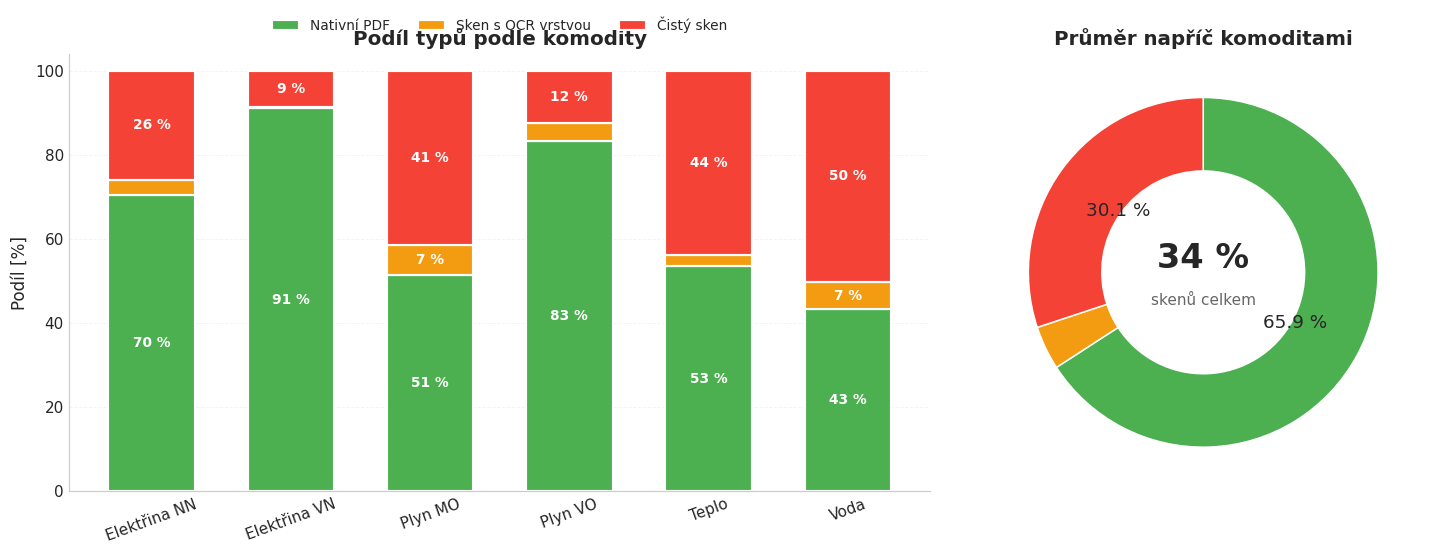

Podíl typů dokumentů [%]:


typ_pdf,Nativní PDF,Sken s OCR vrstvou,Čistý sken
komodita,,,
Elektřina NN,70.4,3.7,25.9
Elektřina VN,91.1,0.2,8.7
Plyn MO,51.4,7.2,41.4
Plyn VO,83.3,4.3,12.4
Teplo,53.4,2.7,43.8
Voda,43.3,6.5,50.2


In [3]:
POPIS_TYPU = {"native": "Nativní PDF", "scan_ocr": "Sken s OCR vrstvou", "scan_image": "Čistý sken"}
BARVY_TYPU = {"native": "#4CAF50", "scan_ocr": "#F39C12", "scan_image": "#F44336"}
PORADI_TYPU = ["native", "scan_ocr", "scan_image"]

podil = (typy.pivot_table(index="komodita", columns="typ_pdf", values="pocet",
                          aggfunc="sum", fill_value=0)
              .reindex(index=KOMODITY, columns=PORADI_TYPU, fill_value=0))
podil_pct = podil.div(podil.sum(axis=1), axis=0) * 100
celkem_pct = podil.sum() / podil.values.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2),
                               gridspec_kw={"width_ratios": [1.7, 1]})

spodek = np.zeros(len(podil_pct))
for typ in PORADI_TYPU:
    hodnoty = podil_pct[typ].to_numpy()
    ax1.bar([NAZVY_KOMODIT[k] for k in podil_pct.index], hodnoty, bottom=spodek,
            color=BARVY_TYPU[typ], label=POPIS_TYPU[typ], width=0.62,
            edgecolor="white", linewidth=1.4)
    for x, (h, s) in enumerate(zip(hodnoty, spodek)):
        if h >= 6:
            ax1.text(x, s + h / 2, f"{h:.0f} %", ha="center", va="center",
                     fontsize=9, fontweight="600", color="white")
    spodek += hodnoty

ax1.set_ylim(0, 104)
uprav_osu(ax1, "Podíl typů podle komodity", y="Podíl [%]")
ax1.legend(frameon=False, fontsize=9, ncol=3, loc="lower center",
           bbox_to_anchor=(0.5, 1.02))
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="x", visible=False)

skeny = celkem_pct["scan_ocr"] + celkem_pct["scan_image"]
ax2.pie(celkem_pct[PORADI_TYPU], colors=[BARVY_TYPU[t] for t in PORADI_TYPU],
        startangle=90, counterclock=False, wedgeprops=dict(width=0.42, edgecolor="white"),
        autopct=lambda p: f"{p:.1f} %" if p > 5 else "")
ax2.text(0, 0.08, f"{skeny:.0f} %", ha="center", va="center", fontsize=22, fontweight="bold")
ax2.text(0, -0.16, "skenů celkem", ha="center", va="center", fontsize=10, color="#666666")
ax2.set_title("Průměr napříč komoditami", fontsize=13, fontweight="semibold")

fig.tight_layout()
plt.show()

print("Podíl typů dokumentů [%]:")
display(tabulka(podil_pct.rename(columns=POPIS_TYPU).rename(index=NAZVY_KOMODIT), desetinna=1))

> **Zjištění.** Skenované faktury tvoří **34 %** datasetu, jsou tedy menšinové —
> zato technologicky nejnáročnější. Podíl se navíc mezi komoditami výrazně liší:
> u elektřiny VN jde o 9 % dokumentů, u vody o 57 %. Systém nemůže spoléhat na
> textovou vrstvu a musí umět zpracovat obraz.

## 1.2 Zastoupení komodit

Rozložení komodit určuje, kam se vyplatí směřovat optimalizaci: chyba u komodity
s velkým objemem faktur má na celkovou kvalitu dat řádově větší dopad.

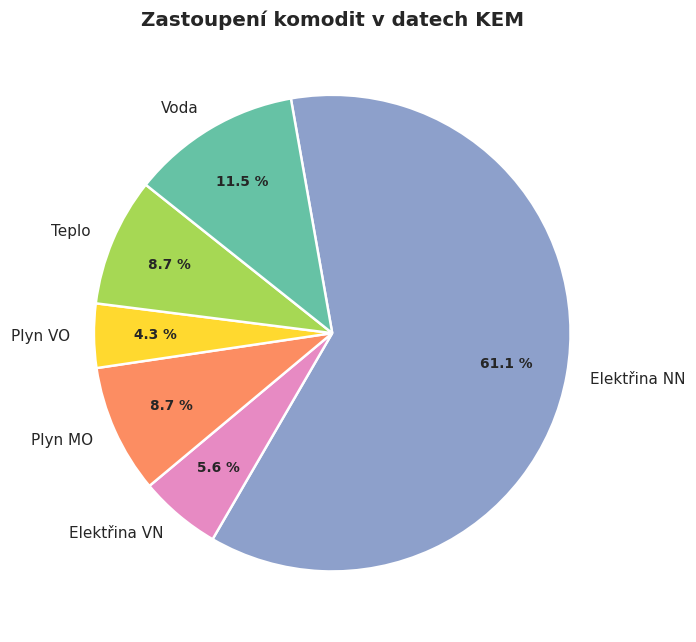

Elektřina celkem: 66.7 %


,podíl [%]
komodita,
Elektřina NN,61.1
Elektřina VN,5.6
Plyn MO,8.7
Plyn VO,4.3
Teplo,8.7
Voda,11.5


In [4]:
komodity_pct = (typy.groupby("komodita").pocet.sum()
                    .reindex(KOMODITY) / typy.pocet.sum() * 100)

fig, ax = plt.subplots(figsize=(8.4, 6))
klinky, _, popisky_pct = ax.pie(
    komodity_pct, labels=[NAZVY_KOMODIT[k] for k in komodity_pct.index],
    colors=[BARVY_KOMODIT[k] for k in komodity_pct.index],
    startangle=100, counterclock=False, autopct="%1.1f %%", pctdistance=0.74,
    wedgeprops=dict(edgecolor="white", linewidth=1.6),
    textprops=dict(fontsize=10))
for popisek in popisky_pct:
    popisek.set_fontsize(9)
    popisek.set_fontweight("600")
ax.set_title("Zastoupení komodit v datech KEM", fontsize=13, fontweight="semibold")
fig.tight_layout()
plt.show()

elektrina = komodity_pct[["elektrina_nn", "elektrina_vn"]].sum()
print(f"Elektřina celkem: {elektrina:.1f} %")
display(tabulka(komodity_pct.rename(NAZVY_KOMODIT).round(1).to_frame("podíl [%]"), desetinna=1))

> **Zjištění.** Dominuje elektřina — **66,7 %** všech faktur (NN 61,1 % + VN 5,6 %).
> Spolu s plynem jde zároveň o technologicky nejsložitější dokumenty s rozsáhlými
> tarifními tabulkami.

## 1.3 Koncentrace dodavatelů

Otázka zní, zda si systém vystačí s pevnými šablonami pro několik velkých
dodavatelů, nebo musí zvládnout i dodavatele, které nikdy neviděl.

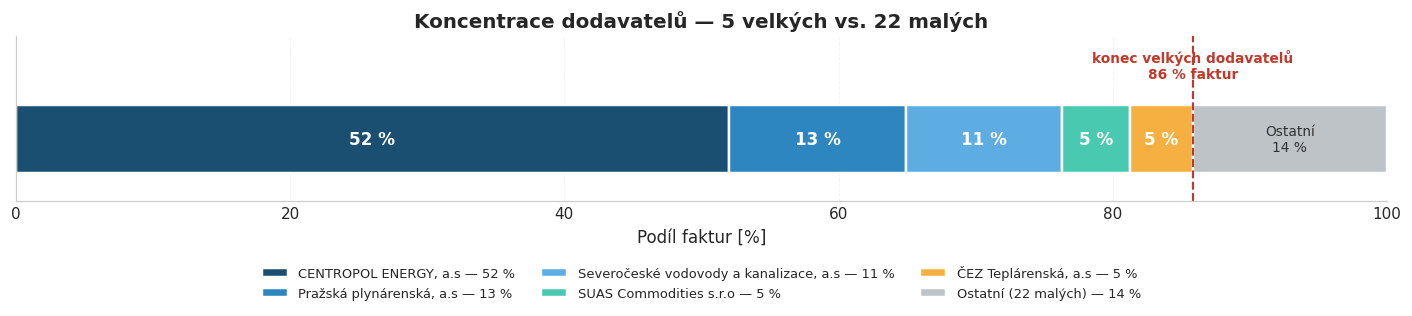

,podíl faktur [%]
dodavatel,
"CENTROPOL ENERGY, a.s",52.0
"Pražská plynárenská, a.s",12.9
"Severočeské vodovody a kanalizace, a.s",11.4
SUAS Commodities s.r.o,5.0
"ČEZ Teplárenská, a.s",4.6
Powertica Energie a.s,3.1
"Pražská energetika, a.s",2.3
"EP ENERGY TRADING, a.s",1.9


In [5]:
dodavatele = (typy.groupby("dodavatel").pocet.sum().sort_values(ascending=False)
                  / typy.pocet.sum() * 100)
VELCI = 5
velci, mali = dodavatele.head(VELCI), dodavatele.iloc[VELCI:]
hranice = velci.sum()

BARVY_VELKYCH = ["#1B4F72", "#2E86C1", "#5DADE2", "#48C9B0", "#F5B041"]

fig, ax = plt.subplots(figsize=(13, 3.4))
levy_okraj = 0.0
for (nazev, hodnota), barva in zip(velci.items(), BARVY_VELKYCH):
    ax.barh(0, hodnota, left=levy_okraj, color=barva, height=0.5,
            edgecolor="white", linewidth=1.6,
            label=f"{nazev} — {hodnota:.0f} %")
    if hodnota >= 4:
        ax.text(levy_okraj + hodnota / 2, 0, f"{hodnota:.0f} %", ha="center",
                va="center", color="white", fontweight="bold", fontsize=11)
    levy_okraj += hodnota
ax.barh(0, mali.sum(), left=levy_okraj, color="#BDC3C7", height=0.5,
        edgecolor="white", linewidth=1.6,
        label=f"Ostatní ({len(mali)} malých) — {mali.sum():.0f} %")
ax.text(levy_okraj + mali.sum() / 2, 0, f"Ostatní\n{mali.sum():.0f} %",
        ha="center", va="center", fontsize=9, color="#333333")

ax.axvline(hranice, color=PRAH, linestyle="--", linewidth=1.4)
ax.text(hranice, 0.42, f"konec velkých dodavatelů\n{hranice:.0f} % faktur",
        ha="center", va="bottom", fontsize=9, color=PRAH, fontweight="600")

ax.set_xlim(0, 100)
ax.set_ylim(-0.45, 0.75)
ax.set_yticks([])
ax.set_xlabel("Podíl faktur [%]")
ax.set_title(f"Koncentrace dodavatelů — {VELCI} velkých vs. {len(mali)} malých",
             fontsize=13, fontweight="semibold")
ax.legend(frameon=False, fontsize=8.5, ncol=3, loc="upper center",
          bbox_to_anchor=(0.5, -0.32))
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

display(tabulka(dodavatele.head(8).round(1).to_frame("podíl faktur [%]"), desetinna=1))

> **Zjištění.** Pět největších dodavatelů pokrývá **86 %** objemu faktur — na jejich
> šablony se vyplatí cílit. Zbylých 14 % ale pochází od **22 malých dodavatelů**,
> každého s vlastním formátem. Systém proto nemůže stát na fixních šablonách
> a musí generalizovat i na neznámé dodavatele; tento požadavek ověřuje
> notebook `08_generalizace_ds3`.

## 1.4 Vizuální kvalita skenů

Ostrost obrazu měříme **rozptylem Laplaceova operátoru** — metoda hledá v obraze
ostré přechody mezi světlými a tmavými místy (hrany písma, linky tabulek). Čím
více takových přechodů dokument obsahuje, tím vyšší hodnotu metoda vrátí;
rozmazaný sken má přechody neostré, a číslo je proto nízké.

Podle terciálů této metriky dělíme dokumenty do tří tříd kvality:

* **Q1** — čisté skeny,
* **Q2** — mírný šum, u kterého klasické OCR chybuje na úrovni znaků,
* **Q3** — silně degradované dokumenty.

Hranice tříd:  Q3 < 3 008  ≤  Q2  <  4 927  ≤  Q1


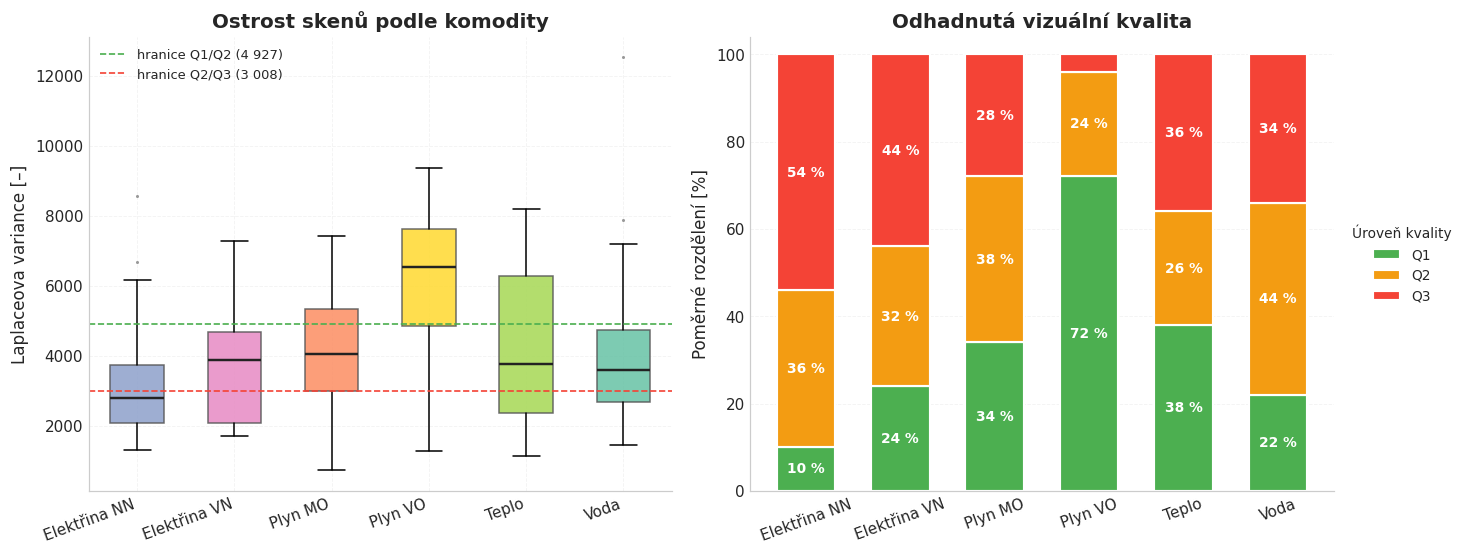

In [6]:
q3_prah, q1_prah = ostrost.lv.quantile([1/3, 2/3])
print(f"Hranice tříd:  Q3 < {q3_prah:,.0f}  ≤  Q2  <  {q1_prah:,.0f}  ≤  Q1".replace(",", " "))

def trida(lv):
    return "Q3" if lv < q3_prah else ("Q2" if lv < q1_prah else "Q1")

ostrost["trida"] = ostrost.lv.map(trida)
BARVY_TRID = {"Q1": "#4CAF50", "Q2": "#F39C12", "Q3": "#F44336"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2))

data_box = [ostrost.loc[ostrost.commodity == k, "lv"].to_numpy() for k in KOMODITY]
bp = ax1.boxplot(data_box, patch_artist=True, widths=0.55,
                 medianprops=dict(color="#222222", linewidth=1.6),
                 flierprops=dict(marker=".", markersize=4, markerfacecolor="#999999",
                                 markeredgecolor="none"))
for telo, k in zip(bp["boxes"], KOMODITY):
    telo.set_facecolor(BARVY_KOMODIT[k])
    telo.set_alpha(0.85)
    telo.set_edgecolor("#555555")
ax1.axhline(q1_prah, color="#4CAF50", linestyle="--", linewidth=1.1,
            label=f"hranice Q1/Q2 ({q1_prah:,.0f})".replace(",", " "))
ax1.axhline(q3_prah, color="#F44336", linestyle="--", linewidth=1.1,
            label=f"hranice Q2/Q3 ({q3_prah:,.0f})".replace(",", " "))
ax1.set_xticklabels([NAZVY_KOMODIT[k] for k in KOMODITY], rotation=20, ha="right")
uprav_osu(ax1, "Ostrost skenů podle komodity", y="Laplaceova variance [–]")
ax1.legend(frameon=False, fontsize=8.5, loc="upper left")

rozdeleni = (ostrost.pivot_table(index="commodity", columns="trida", values="lv",
                                 aggfunc="size", fill_value=0)
                    .reindex(index=KOMODITY, columns=["Q1", "Q2", "Q3"], fill_value=0))
rozdeleni_pct = rozdeleni.div(rozdeleni.sum(axis=1), axis=0) * 100
spodek = np.zeros(len(rozdeleni_pct))
for t in ["Q1", "Q2", "Q3"]:
    hodnoty = rozdeleni_pct[t].to_numpy()
    ax2.bar([NAZVY_KOMODIT[k] for k in rozdeleni_pct.index], hodnoty, bottom=spodek,
            color=BARVY_TRID[t], label=t, width=0.62, edgecolor="white", linewidth=1.4)
    for x, (h, s) in enumerate(zip(hodnoty, spodek)):
        if h >= 8:
            ax2.text(x, s + h / 2, f"{h:.0f} %", ha="center", va="center",
                     fontsize=9, fontweight="600", color="white")
    spodek += hodnoty
ax2.set_ylim(0, 104)
uprav_osu(ax2, "Odhadnutá vizuální kvalita", y="Poměrné rozdělení [%]")
ax2.legend(title="Úroveň kvality", frameon=False, fontsize=9, title_fontsize=9,
           loc="center left", bbox_to_anchor=(1.01, 0.5))
ax2.tick_params(axis="x", rotation=20)
ax2.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

> **Zjištění.** Rozložení kvality se mezi komoditami výrazně liší — u elektřiny NN
> spadá do nejhorší třídy Q3 přes polovinu vzorku, u plynu VO čtvrtina. Právě na
> třídě Q3 se ukáže, zda multimodální model dokáže díky širšímu kontextu přečíst
> i degradovaný text; vyhodnocuje to akceptační kritérium K9 v notebooku
> `07_evaluace_ds1`.

## 1.5 Rozsah dokumentů

Počet stran určuje, jak velké kontextové okno model potřebuje. U dlouhých
dokumentů navíc roste riziko, že model ke konci textu ztratí pozornost.

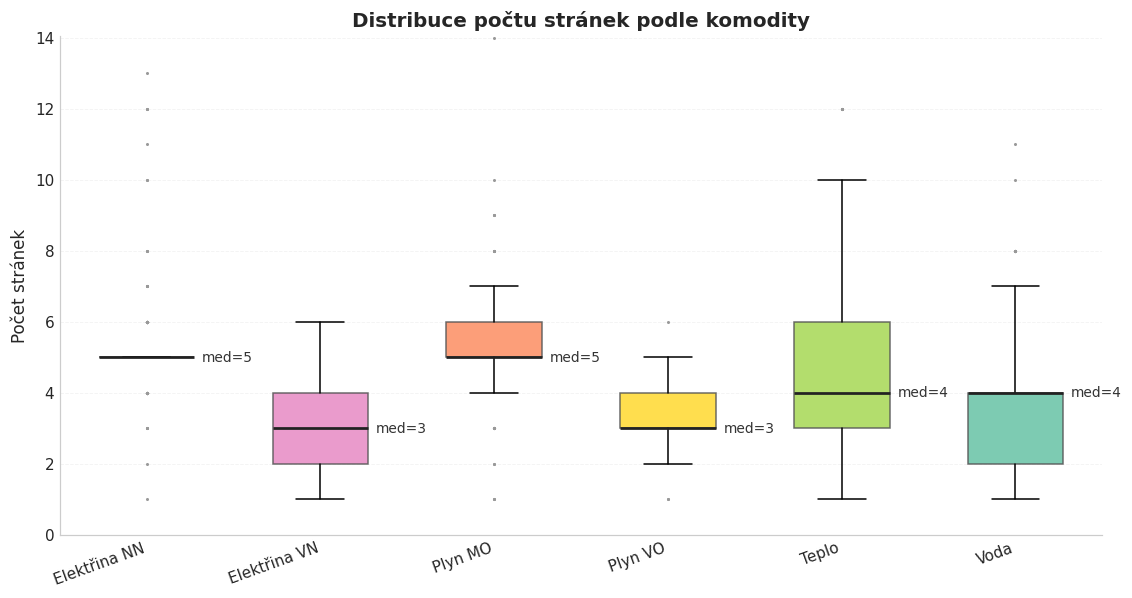

,medián,průměr,maximum
komodita,,,
Elektřina NN,5.0,5.5,62
Elektřina VN,3.0,3.0,6
Plyn MO,5.0,5.1,16
Plyn VO,3.0,3.3,6
Teplo,4.0,5.0,22
Voda,4.0,3.8,11


In [7]:
fig, ax = plt.subplots(figsize=(10.5, 5.6))
data_box = [strany.loc[strany.komodita == k, "pocet_stran"].to_numpy() for k in KOMODITY]
bp = ax.boxplot(data_box, patch_artist=True, widths=0.55, showfliers=True,
                medianprops=dict(color="#222222", linewidth=1.8),
                flierprops=dict(marker=".", markersize=4, markerfacecolor="#999999",
                                markeredgecolor="none"))
for telo, k in zip(bp["boxes"], KOMODITY):
    telo.set_facecolor(BARVY_KOMODIT[k])
    telo.set_alpha(0.85)
    telo.set_edgecolor("#555555")

for i, k in enumerate(KOMODITY, start=1):
    median = int(strany.loc[strany.komodita == k, "pocet_stran"].median())
    ax.text(i + 0.32, median, f"med={median}", va="center", fontsize=9, color="#333333")

horni = strany.groupby("komodita").pocet_stran.quantile(0.99).max()
ax.set_ylim(0, horni + 2)
ax.set_xticklabels([NAZVY_KOMODIT[k] for k in KOMODITY], rotation=20, ha="right")
uprav_osu(ax, "Distribuce počtu stránek podle komodity", y="Počet stránek")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

prehled = (strany.groupby("komodita").pocet_stran
                 .agg(medián="median", průměr="mean", maximum="max")
                 .reindex(KOMODITY).rename(index=NAZVY_KOMODIT))
display(tabulka(prehled, desetinna=1))

> **Zjištění.** Většina faktur má 3 až 8 stran, u velkoodběrů elektřiny a plynu
> dosahuje vyúčtování až 12 stran. Prompt proto musí být navržen tak, aby model
> udržel pozornost i na konci dlouhého dokumentu.

## Závěr kapitoly

| Zjištění | Důsledek pro návrh systému |
|---|---|
| 34 % dokumentů jsou skeny, u vody až 57 % | Nelze spoléhat na textovou vrstvu — nutné OCR nebo multimodální model |
| Elektřina tvoří 66,7 % faktur | Optimalizace míří především na elektřinu a plyn |
| 5 dodavatelů = 86 % faktur, 22 malých = 14 % | Fixní šablony nestačí, systém musí generalizovat |
| Třetina skenů spadá do nejhorší třídy Q3 | Robustnost vůči degradaci je akceptační kritérium (K9) |
| Faktury mají 3–12 stran | Prompt musí zvládnout dlouhý kontext |

Na základě těchto zjištění byly sestaveny tři datové sady:

| Sada | Účel | Rozsah | Zdroj |
|---|---|---|---|
| **DS1** | finální evaluace (held-out) | 573 faktur, 19 dodavatelů | reálné faktury KEM |
| **DS2** | vývoj a ladění promptů | 180 faktur, 8 dodavatelů | reálné faktury KEM |
| **DS3** | test generalizace (zero-shot) | 162 faktur, 18 fiktivních dodavatelů | syntetické PDF |

Následující notebooky `02`–`06` pracují výhradně se sadou **DS2**, aby zůstala
DS1 nedotčená pro závěrečné vyhodnocení.